# PlantVillage disease classifier
Put the extracted Mendeley dataset in `ai_model/dataset/` so that it holds one sub-folder per class (e.g. `dataset/Tomato___Late_blight/*.jpg`). If the zip has an extra wrapper folder, set `DATA_DIR` to it.

In [2]:
import os, json, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
DATA_DIR = r"C:\Users\saiga\Desktop\smart-crop-protection\dataset"         # <- change if your class folders sit deeper
IMG, BATCH, EPOCHS, SEED = (224, 224), 32, 8, 42
print(tf.__version__, tf.config.list_physical_devices('GPU'))

2.16.2 []


## Load data

In [3]:
kw = dict(validation_split=0.2, seed=SEED, image_size=IMG, batch_size=BATCH)
train_ds = tf.keras.utils.image_dataset_from_directory(DATA_DIR, subset='training', **kw)
val_ds   = tf.keras.utils.image_dataset_from_directory(DATA_DIR, subset='validation', shuffle=False, **kw)
class_names = train_ds.class_names
print(len(class_names), 'classes')
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE); val_ds = val_ds.prefetch(AUTOTUNE)

Found 61486 files belonging to 39 classes.
Using 49189 files for training.
Found 61486 files belonging to 39 classes.
Using 12297 files for validation.
39 classes


## Augmentation + model (MobileNetV2 transfer learning)
Preprocessing is built into the model, so the backend feeds raw 0-255 pixels.

In [4]:
aug = tf.keras.Sequential([layers.RandomFlip('horizontal_and_vertical'), layers.RandomRotation(0.15),
                          layers.RandomZoom(0.15), layers.RandomContrast(0.15)])
base = tf.keras.applications.MobileNetV2(input_shape=IMG+(3,), include_top=False, weights='imagenet')
base.trainable = False
inp = layers.Input(IMG+(3,))
x = aug(inp)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(len(class_names), activation='softmax')(x)
model = models.Model(inp, out)
model.compile('adam', 'sparse_categorical_crossentropy', metrics=['accuracy'])

## Train

In [5]:
cb = [tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)]
hist = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cb)

Epoch 1/8
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1050s 680ms/step - accuracy: 0.8264 - loss: 0.6051 - val_accuracy: 0.8574 - val_loss: 0.4590
Epoch 2/8
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1072s 697ms/step - accuracy: 0.9000 - loss: 0.3112 - val_accuracy: 0.8942 - val_loss: 0.3461
Epoch 3/8
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1094s 711ms/step - accuracy: 0.9098 - loss: 0.2774 - val_accuracy: 0.8944 - val_loss: 0.3137
Epoch 4/8
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1053s 685ms/step - accuracy: 0.9150 - loss: 0.2620 - val_accuracy: 0.8748 - val_loss: 0.3622
Epoch 5/8
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 1012s 658ms/step - accuracy: 0.9175 - loss: 0.2546 - val_accuracy: 0.8909 - val_loss: 0.3230


## Evaluate: accuracy/loss graphs and confusion matrix

Found 61486 files belonging to 39 classes.
Using 12297 files for validation.


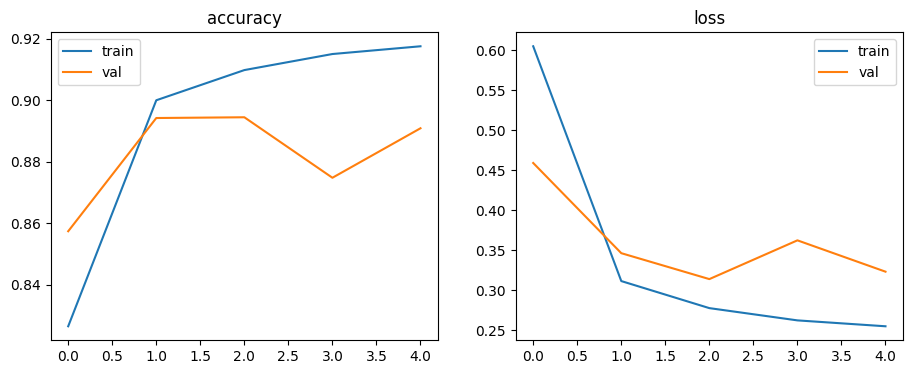

Validation accuracy: 92.57 %
                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.98      0.77      0.86       202
                            Apple___Black_rot       0.95      0.97      0.96       213
                     Apple___Cedar_apple_rust       0.96      0.96      0.96       197
                              Apple___healthy       0.83      1.00      0.90       317
                    Background_without_leaves       1.00      0.98      0.99       258
                          Blueberry___healthy       0.99      0.98      0.99       295
                      Cherry___Powdery_mildew       1.00      0.94      0.97       197
                             Cherry___healthy       0.97      0.97      0.97       197
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.77      0.84       190
                           Corn___Common_rust       1.00      1.00      1.00       279
             

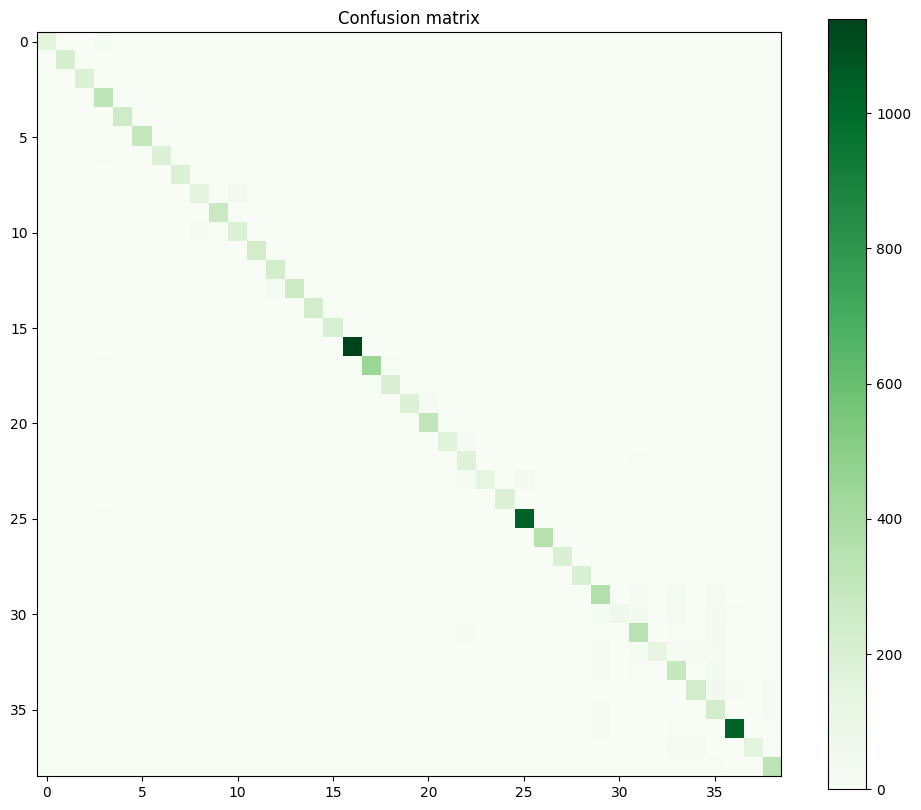

In [8]:
# Rebuild validation set correctly (same seed/split as training, no shuffle=False bug)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset='validation', seed=SEED, image_size=IMG, batch_size=BATCH)

# Accuracy / loss graphs
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, k in zip(ax, ['accuracy', 'loss']):
    a.plot(hist.history[k], label='train'); a.plot(hist.history['val_'+k], label='val'); a.set_title(k); a.legend()
plt.show()

# Predictions and true labels collected in the same pass, so they always line up
y_true, y_pred = [], []
for x, y in val_ds:
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(model.predict(x, verbose=0), axis=1))
y_true, y_pred = np.array(y_true), np.array(y_pred)

print('Validation accuracy:', round((y_true == y_pred).mean() * 100, 2), '%')
print(classification_report(y_true, y_pred, labels=range(len(class_names)), target_names=class_names))

cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
plt.figure(figsize=(12, 10)); plt.imshow(cm, cmap='Greens'); plt.title('Confusion matrix'); plt.colorbar(); plt.show()

## Save model (used by the backend; never retrained at upload time)

In [9]:
model.save('trained_model.keras')
json.dump(class_names, open('class_names.json', 'w'))
print('saved trained_model.keras and class_names.json')

saved trained_model.keras and class_names.json
